<div style="
    background: linear-gradient(135deg, #ffffff, #fffdfd);
    color: #5c1d0c;
    padding: 22px;
    border-left: 6px solid #E24307;
    border-radius: 12px;
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0px 4px 12px rgba(0,0,0,0.15);
">
  <div style="display: flex; align-items: center; gap: 12px;">
    <img src="data/logo-swift.png" alt="Logo Swift" style="height: 45px;">
    <h2 style="color: #E24307; margin: 0; text-transform: uppercase; letter-spacing: 1px; font-size: 24px;">
      Análise de NPS - Swift
    </h2>
  </div>
  <hr style="border: 0; border-top: 1px solid #f4b39a; margin: 15px 0;">
  <p style="margin: 8px 0;">
    <b style="color:#a12d00;">Membros:</b>
    <span style="color: #5f3a2d; font-size: 13px;">
      Gabriel Martins Oliveira | Leticia Nascimento da Silva |
      Theo Correia Martins | Vitor De Mello Maciel
    </span>
  </p>
  <p style="margin: 8px 0;">
    <b style="color:#a12d00;">Data Entrega:</b>
    <span style="color: #5f3a2d; font-size: 13px;">xx/xx/xxxx</span>
  </p>
</div>

<div style="
    background-color: #fff4ee;
    padding: 25px;
    border-radius: 15px;
    font-family: Arial, sans-serif;
    border-left: 6px solid #E24307;
    box-shadow: 0px 2px 8px rgba(0,0,0,0.1);
">
    <h2 style="color: #E24307; margin-top: 0; margin-bottom: 15px; font-size: 28px;">
        Objetivo do Projeto
    </h2>
    <div style="background-color: white; padding: 18px; border-radius: 10px; border: 1px solid #ffd2c2;">
        <p style="color: #5f3a2d; font-size: 14px; line-height: 1.8; text-align: justify;">
            Este projeto tem como objetivo analisar os dados de
            <b style="color:#E24307;">NPS (Net Promoter Score)</b>
            das lojas Swift, buscando identificar padrões de satisfação dos clientes e comparar o desempenho entre gerentes
            <b style="color:#E24307;">REGULAR</b> e
            <b style="color:#E24307;">TOCADORA</b>.
            <br><br>
            A análise envolve tanto dados quantitativos quanto qualitativos, utilizando técnicas de
            <b style="color:#E24307;">EDA</b>,
            <b style="color:#E24307;">NLP</b>
            e visualização de dados.
            <br><br>
            Além do cálculo e acompanhamento do NPS, o projeto propõe a análise de sentimentos dos comentários dos clientes,
            categorização automática por áreas de atendimento (produto, limpeza, atendimento, abastecimento e cultura de produtos)
            e clusterização textual para identificação de padrões nas avaliações.
            <br><br>
            Como resultado, espera-se gerar
            <b style="color:#E24307;">insights estratégicos</b>
            que auxiliem na compreensão da experiência do cliente e apoiem a tomada de decisão gerencial.
        </p>
    </div>
</div>

---

### Índice

1. Imports & Configurações
2. Carregamento dos Dados
3. Inspeção Inicial
4. Limpeza e Padronização
5. Tratamento de Datas
6. Tratamento de Texto (Comentários)
7. Merge das Bases
8. Feature Engineering
9. Detecção de Outliers
10. Análise Exploratória
11. Exportação

---

<div style="
    background: linear-gradient(90deg, #ff632a 0%, #ffefea 100%);
    border-left: 6px solid #7e2200;
    color: white;
    padding: 12px 20px;
    border-radius: 8px;
    font-family: 'Segoe UI', sans-serif;
    font-size: 16px;
    font-weight: bold;
    letter-spacing: 0.5px;
    margin: 10px 0 5px 0;
    box-shadow: 0px 2px 6px rgba(226,67,7,0.3);
"> 1. Imports & Configurações</div>

In [22]:
import pandas as pd
import numpy as np
import re
import warnings
import json
import unicodedata
import string
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Estatísticas
from scipy import stats

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')

CORES = {'promotor': '#2ecc71', 'neutro': '#f39c12', 'detrator': '#e74c3c'}
CORES_FLAG = {'REGULAR': '#3498db', 'TOCADORA': '#9b59b6'}

print(' Imports carregados com sucesso!')
print(f'   Pandas  : {pd.__version__}')
print(f'   NumPy   : {np.__version__}')

 Imports carregados com sucesso!
   Pandas  : 3.0.3
   NumPy   : 2.4.6


<div style="
    background: linear-gradient(90deg, #ff632a 0%, #ffefea 100%);
    border-left: 6px solid #7e2200;    color: white;
    padding: 12px 20px;
    border-radius: 8px;
    font-family: 'Segoe UI', sans-serif;
    font-size: 16px;
    font-weight: bold;
    letter-spacing: 0.5px;
    margin: 10px 0 5px 0;
    box-shadow: 0px 2px 6px rgba(226,67,7,0.3);
"> 2. Carregamento dos Dados</div>

In [23]:
PATH_AVALIACOES = 'data\Dados para o Grillo.xlsx' 
PATH_TRANSACOES = 'data\Transacoes Lojas.xlsx'       

df_aval  = pd.read_excel(PATH_AVALIACOES)
df_trans = pd.read_excel(PATH_TRANSACOES)

print(f' Avaliações : {df_aval.shape[0]:,} linhas | {df_aval.shape[1]} colunas')
print(f' Transações : {df_trans.shape[0]:,} linhas | {df_trans.shape[1]} colunas')

 Avaliações : 240,352 linhas | 7 colunas
 Transações : 3,645 linhas | 6 colunas


<div style="
    background: linear-gradient(90deg, #ff632a 0%, #ffefea 100%);
    border-left: 6px solid #7e2200;
    color: white;
    padding: 12px 20px;
    border-radius: 8px;
    font-family: 'Segoe UI', sans-serif;
    font-size: 16px;
    font-weight: bold;
    letter-spacing: 0.5px;
    margin: 10px 0 5px 0;
    box-shadow: 0px 2px 6px rgba(226,67,7,0.3);
"> 3. Inspeção Inicial</div>

In [24]:
print('=== AVALIAÇÕES — Primeiras linhas ===')
display(df_aval.head(10))

print('\n=== AVALIAÇÕES — Info ===')
df_aval.info()

print('\n=== AVALIAÇÕES — Nulos e % ===')
nulos = pd.DataFrame({
    'Nulos': df_aval.isnull().sum(),
    '%': (df_aval.isnull().mean() * 100).round(2)
})
display(nulos[nulos['Nulos'] > 0])

print('\n=== AVALIAÇÕES — Estatísticas descritivas ===')
display(df_aval.describe(include='all'))

print('\n=== TRANSAÇÕES — Primeiras linhas ===')
display(df_trans.head())
print()
df_trans.info()

=== AVALIAÇÕES — Primeiras linhas ===


,Mes Ano,classificacao,Data Avaliação,CentroNv2,qtd_clientes,Comentario,Flag
0,2025-01-01,promotor,2025-01-01 00:00:00,L5001-RIBEIRAO PRETO (0217),6,-,REGULAR
1,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,REGULAR
2,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",REGULAR
3,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Melhorar o preço!,REGULAR
4,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,-,REGULAR
5,2025-01-01,promotor,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),16,-,REGULAR
6,2025-01-01,promotor,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Alguns produtos com porções menores.,REGULAR
7,2025-01-01,promotor,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Estão de parabéns,REGULAR
8,2025-01-01,promotor,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Os preços estão subindo muito rapidamente e o peso dos produtos nas embalagens estão diminuindo.,REGULAR
9,2025-01-01,promotor,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Seria muito interessante ter a opção de adquirir a carne fatiada na hora.,REGULAR



=== AVALIAÇÕES — Info ===
<class 'pandas.DataFrame'>
RangeIndex: 240352 entries, 0 to 240351
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Mes Ano         240352 non-null  datetime64[us]
 1   classificacao   240352 non-null  str           
 2   Data Avaliação  240352 non-null  object        
 3   CentroNv2       240352 non-null  str           
 4   qtd_clientes    240352 non-null  int64         
 5   Comentario      240352 non-null  str           
 6   Flag            239595 non-null  str           
dtypes: datetime64[us](1), int64(1), object(1), str(4)
memory usage: 12.8+ MB

=== AVALIAÇÕES — Nulos e % ===


,Nulos,%
Flag,757,0.31



=== AVALIAÇÕES — Estatísticas descritivas ===


,Mes Ano,classificacao,Data Avaliação,CentroNv2,qtd_clientes,Comentario,Flag
count,240352,240352,240352,240352,240352.00,240352,239595
unique,NaN,4,504,228,NaN,114609,2
top,NaN,promotor,2025-06-03 00:00:00,L5230-LARGO DO MACHADO,NaN,-,REGULAR
freq,NaN,196526,1114,2544,NaN,112010,183135
mean,2025-08-28 21:40:41.179603,NaN,NaN,NaN,2.01,NaN,NaN
min,2025-01-01 00:00:00,NaN,NaN,NaN,0.00,NaN,NaN
25%,2025-05-01 00:00:00,NaN,NaN,NaN,1.00,NaN,NaN
50%,2025-09-01 00:00:00,NaN,NaN,NaN,1.00,NaN,NaN
75%,2026-01-01 00:00:00,NaN,NaN,NaN,2.00,NaN,NaN
max,2026-05-01 00:00:00,NaN,NaN,NaN,52.00,NaN,NaN



=== TRANSAÇÕES — Primeiras linhas ===


,CentroNv2,Mes Ano,Regiao_IM,Municipio,UF,Transações
0,L5001-RIBEIRAO PRETO (0217),2025-01-01,Interior,RIBEIRÃO PRETO,SP,9738
1,L5002-ALPHAVILLE (0290),2025-01-01,RMSP,BARUERI,SP,7890
2,L5003-LINS (0340),2025-01-01,Interior,LINS,SP,7111
3,L5004-CAMPO BELO (0448),2025-01-01,Capital,SÃO PAULO,SP,6446
4,L5005-BROOKLIN (0475),2025-01-01,Capital,SÃO PAULO,SP,5827



<class 'pandas.DataFrame'>
RangeIndex: 3645 entries, 0 to 3644
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   CentroNv2   3645 non-null   str           
 1   Mes Ano     3645 non-null   datetime64[us]
 2   Regiao_IM   3645 non-null   str           
 3   Municipio   3645 non-null   str           
 4   UF          3645 non-null   str           
 5   Transações  3645 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 171.0 KB


<div style="
    background: linear-gradient(90deg, #ff632a 0%, #ffefea 100%);
    border-left: 6px solid #7e2200;
    color: white;
    padding: 12px 20px;
    border-radius: 8px;
    font-family: 'Segoe UI', sans-serif;
    font-size: 16px;
    font-weight: bold;
    letter-spacing: 0.5px;
    margin: 10px 0 5px 0;
    box-shadow: 0px 2px 6px rgba(226,67,7,0.3);
"> 4. Limpeza e Padronização</div>

In [25]:
# ── 4.1 Cópias de trabalho ──────────────────────────────────────────────────
df   = df_aval.copy()
df_t = df_trans.copy()

# ── 4.2 Renomear colunas (padronização snake_case) ──────────────────────────
rename_aval = {
    'Mes Ano'         : 'mes_ano',
    'classificacao'   : 'classificacao',
    'Data Avaliacao'  : 'data_avaliacao',
    'Data Avaliação'  : 'data_avaliacao',
    'CentroNv2'       : 'centro_nv2',
    'qtd_clientes'    : 'qtd_clientes',
    'Comentario'      : 'comentario',
    'Flag'            : 'flag',
}
rename_trans = {
    'CentroNv2'  : 'centro_nv2',
    'Mes Ano'    : 'mes_ano',
    'Regiao_IM'  : 'regiao',
    'Municipio'  : 'municipio',
    'UF'         : 'uf',
    'Transacoes' : 'transacoes',
    'Transações' : 'transacoes',
}

df   = df.rename(columns=rename_aval)
df_t = df_t.rename(columns=rename_trans)

print(' Colunas renomeadas')
print('Avaliações :', list(df.columns))
print('Transações :', list(df_t.columns))

 Colunas renomeadas
Avaliações : ['mes_ano', 'classificacao', 'data_avaliacao', 'centro_nv2', 'qtd_clientes', 'comentario', 'flag']
Transações : ['centro_nv2', 'mes_ano', 'regiao', 'municipio', 'uf', 'transacoes']


In [26]:
# ── 4.3 Padronizar strings ──────────────────────────────────────────────────
str_cols_lower = ['classificacao', 'flag']
str_cols_upper = ['centro_nv2']

for col in str_cols_lower:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

for col in str_cols_upper:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()

df_t['centro_nv2'] = df_t['centro_nv2'].astype(str).str.strip().str.upper()

print('Classificações únicas :', df['classificacao'].unique())
print('Flags únicas          :', df['flag'].unique())

# ── 4.4 Tratar flag: garantir apenas REGULAR / TOCADORA ─────────────────────
flags_validas = {'regular', 'tocadora'}
mask_flag_inv = ~df['flag'].isin(flags_validas)
print(f'\nRegistros com flag inválida: {mask_flag_inv.sum()}')
if mask_flag_inv.sum() > 0:
    display(df[mask_flag_inv][['centro_nv2', 'flag']].value_counts().reset_index())

# ── 4.5 Tratar classificação ─────────────────────────────────────────────────
class_validas = {'promotor', 'neutro', 'detrator'}
mask_class_inv = ~df['classificacao'].isin(class_validas)
print(f'\nRegistros com classificação inválida: {mask_class_inv.sum()}')
if mask_class_inv.sum() > 0:
    display(df[mask_class_inv]['classificacao'].value_counts())

# ── 4.6 Tratar qtd_clientes ──────────────────────────────────────────────────
df['qtd_clientes'] = pd.to_numeric(df['qtd_clientes'], errors='coerce')
print(f'\nqtd_clientes <= 0 : {(df["qtd_clientes"] <= 0).sum()}')
print(f'qtd_clientes nulo : {df["qtd_clientes"].isnull().sum()}')
df = df[df['qtd_clientes'] > 0].copy()

# ── 4.7 Tratar coluna de transações (separador de milhar / vírgula decimal) ──
if df_t['transacoes'].dtype == object:
    df_t['transacoes'] = (
        df_t['transacoes']
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
df_t['transacoes'] = pd.to_numeric(df_t['transacoes'], errors='coerce')
print(f'\nTransações nulas : {df_t["transacoes"].isnull().sum()}')

# ── 4.8 Duplicatas ───────────────────────────────────────────────────────────
dup_aval  = df.duplicated().sum()
dup_trans = df_t.duplicated().sum()
print(f'\nDuplicatas em avaliações : {dup_aval}')
print(f'Duplicatas em transações : {dup_trans}')
df   = df.drop_duplicates()
df_t = df_t.drop_duplicates()
print('✅ Limpeza concluída')
print(f'   Shape avaliações : {df.shape}')
print(f'   Shape transações : {df_t.shape}')

Classificações únicas : <StringArray>
['promotor', 'neutro', 'detrator', '-']
Length: 4, dtype: str
Flags únicas          : <StringArray>
['regular', 'tocadora', nan]
Length: 3, dtype: str

Registros com flag inválida: 757


,centro_nv2,flag,count



Registros com classificação inválida: 454


classificacao
-    454
Name: count, dtype: int64


qtd_clientes <= 0 : 454
qtd_clientes nulo : 0

Transações nulas : 0

Duplicatas em avaliações : 0
Duplicatas em transações : 0
✅ Limpeza concluída
   Shape avaliações : (239898, 7)
   Shape transações : (3645, 6)


<div style="
    background: linear-gradient(90deg, #ff632a 0%, #ffefea 100%);
    border-left: 6px solid #7e2200;
    color: white;
    padding: 12px 20px;
    border-radius: 8px;
    font-family: 'Segoe UI', sans-serif;
    font-size: 16px;
    font-weight: bold;
    letter-spacing: 0.5px;
    margin: 10px 0 5px 0;
    box-shadow: 0px 2px 6px rgba(226,67,7,0.3);
"> 5. Tratamento de Datas</div>

In [27]:
# ── 5.1 data_avaliacao → datetime ────────────────────────────────────────────
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], dayfirst=True, errors='coerce')
datas_nulas = df['data_avaliacao'].isnull().sum()
print(f'  Datas inválidas (NaT): {datas_nulas}')

# ── 5.2 Extrair componentes temporais ────────────────────────────────────────
df['ano']             = df['data_avaliacao'].dt.year
df['mes']             = df['data_avaliacao'].dt.month
df['trimestre']       = df['data_avaliacao'].dt.quarter
df['semana_ano']      = df['data_avaliacao'].dt.isocalendar().week.astype('Int64')
df['dia_semana']      = df['data_avaliacao'].dt.dayofweek          # 0 = segunda
df['dia_semana_nome'] = df['data_avaliacao'].dt.day_name(locale='pt_BR')

# Period para ordenação correta em gráficos
df['mes_ano_dt'] = df['data_avaliacao'].dt.to_period('M')

# Transações: mes_ano em formato 'JAN/2025' → Period
df_t['mes_ano_dt'] = pd.to_datetime(
    df_t['mes_ano'], format='%b/%Y', errors='coerce'
).dt.to_period('M')

# ── 5.3 Sanity check: data_avaliacao dentro do mes_ano ───────────────────────
df['_mes_ano_period'] = pd.to_datetime(
    df['mes_ano'], format='%b/%Y', errors='coerce'
).dt.to_period('M')

inconsistentes = df[
    df['mes_ano_dt'].notna() & df['_mes_ano_period'].notna() &
    (df['mes_ano_dt'] != df['_mes_ano_period'])
]
print(f'  Registros com data_avaliacao fora do mes_ano: {len(inconsistentes)}')
if len(inconsistentes):
    display(inconsistentes[['mes_ano', 'data_avaliacao', 'mes_ano_dt', '_mes_ano_period']].head(10))

df = df.drop(columns=['_mes_ano_period'])

print(' Datas processadas')
display(df[['data_avaliacao', 'ano', 'mes', 'dia_semana_nome', 'trimestre', 'semana_ano']].head())

  Datas inválidas (NaT): 0
  Registros com data_avaliacao fora do mes_ano: 0
 Datas processadas


,data_avaliacao,ano,mes,dia_semana_nome,trimestre,semana_ano
0,2025-01-01,2025,1,Quarta-feira,1,1
1,2025-01-02,2025,1,Quinta-feira,1,1
2,2025-01-02,2025,1,Quinta-feira,1,1
3,2025-01-02,2025,1,Quinta-feira,1,1
4,2025-01-02,2025,1,Quinta-feira,1,1


<div style="
    background: linear-gradient(90deg, #ff632a 0%, #ffefea 100%);
    border-left: 6px solid #7e2200;
    color: white;
    padding: 12px 20px;
    border-radius: 8px;
    font-family: 'Segoe UI', sans-serif;
    font-size: 16px;
    font-weight: bold;
    letter-spacing: 0.5px;
    margin: 10px 0 5px 0;
    box-shadow: 0px 2px 6px rgba(226,67,7,0.3);
"> 6. Tratamento de Texto (Comentários)</div>

In [28]:
# ── 6.1 Identificar comentários ausentes / placeholder ───────────────────────
PLACEHOLDERS = {'-', 'nan', 'none', '', 'n/a', 'nenhum', 'sem comentario',
                'sem comentário', 'nada', 'ok', 'ótimo', 'otimo'}

df['comentario_raw'] = df['comentario'].astype(str).str.strip()
df['tem_comentario'] = ~df['comentario_raw'].str.lower().isin(PLACEHOLDERS)

print(f'Registros COM comentário real : {df["tem_comentario"].sum():,}')
print(f'Registros SEM comentário real : {(~df["tem_comentario"]).sum():,}')
print(f'Taxa de comentários           : {df["tem_comentario"].mean()*100:.1f}%')

Registros COM comentário real : 128,333
Registros SEM comentário real : 111,565
Taxa de comentários           : 53.5%


In [29]:
# ── 6.2 Função de limpeza de texto ───────────────────────────────────────────
def limpar_texto(texto: str) -> str:
    """Limpeza básica preservando estrutura semântica para NLP."""
    if not isinstance(texto, str):
        return ''
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\b\d+\b', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df['comentario_limpo'] = df.apply(
    lambda r: limpar_texto(r['comentario_raw']) if r['tem_comentario'] else '',
    axis=1
)

print(' Texto limpo')
display(df[df['tem_comentario']][['comentario_raw', 'comentario_limpo']].head(8))

 Texto limpo


,comentario_raw,comentario_limpo
1,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,bastante falta de produto talvez pela data mas nao tinha muita coisa principalmente bovino
2,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",estrutura excelente mas os pecos deveriam ser melhores ou equivalentes aos mercados de carnes
3,Melhorar o preço!,melhorar o preco
6,Alguns produtos com porções menores.,alguns produtos com porcoes menores
7,Estão de parabéns,estao de parabens
8,Os preços estão subindo muito rapidamente e o peso dos produtos nas embalagens estão diminuindo.,os precos estao subindo muito rapidamente e o peso dos produtos nas embalagens estao diminuindo
9,Seria muito interessante ter a opção de adquirir a carne fatiada na hora.,seria muito interessante ter a opcao de adquirir a carne fatiada na hora
10,Os preços estão acima do praticado no mercado.\nEsse é o único ponto negativo da rede como um todo.,os precos estao acima do praticado no mercado esse e o unico ponto negativo da rede como um todo


Média de palavras por comentário : 15.9
Mediana                          : 9


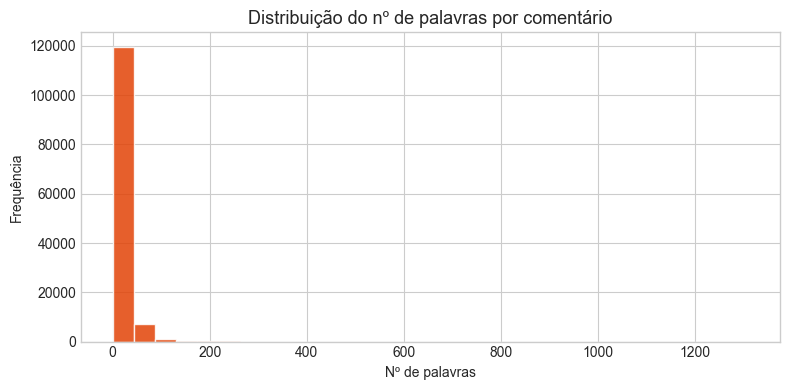

In [30]:
# ── 6.3 Métricas básicas do texto ────────────────────────────────────────────
df['qtd_chars']    = df['comentario_limpo'].str.len()
df['qtd_palavras'] = df['comentario_limpo'].str.split().str.len().fillna(0).astype(int)

comentarios_validos = df[df['tem_comentario']]
print(f'Média de palavras por comentário : {comentarios_validos["qtd_palavras"].mean():.1f}')
print(f'Mediana                          : {comentarios_validos["qtd_palavras"].median():.0f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(comentarios_validos['qtd_palavras'], bins=30, color='#E24307', edgecolor='white', alpha=0.85)
ax.set_title('Distribuição do nº de palavras por comentário', fontsize=13)
ax.set_xlabel('Nº de palavras')
ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

In [31]:
# ── 6.4 Stopwords em português ───────────────────────────────────────────────
try:
    import nltk
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords
    STOPWORDS_PT = set(stopwords.words('portuguese'))
    print(f' Stopwords NLTK carregadas: {len(STOPWORDS_PT)} palavras')
except Exception as e:
    print(f'  NLTK não disponível ({e}). Usando lista mínima.')
    STOPWORDS_PT = {
        'a','o','e','de','do','da','em','um','uma','que','se','na','no',
        'para','com','por','mais','mas','ao','os','as','dos','das','eu',
        'me','meu','minha','meus','minhas','é','ser','foi','tem','ter'
    }

def remover_stopwords(texto: str) -> str:
    if not texto:
        return ''
    return ' '.join(w for w in texto.split() if w not in STOPWORDS_PT)

df['comentario_sem_sw'] = df['comentario_limpo'].apply(remover_stopwords)

print(' Coluna comentario_sem_sw criada')
display(df[df['tem_comentario']][['comentario_limpo', 'comentario_sem_sw']].head(5))

 Stopwords NLTK carregadas: 207 palavras
 Coluna comentario_sem_sw criada


,comentario_limpo,comentario_sem_sw
1,bastante falta de produto talvez pela data mas nao tinha muita coisa principalmente bovino,bastante falta produto talvez data nao muita coisa principalmente bovino
2,estrutura excelente mas os pecos deveriam ser melhores ou equivalentes aos mercados de carnes,estrutura excelente pecos deveriam melhores equivalentes mercados carnes
3,melhorar o preco,melhorar preco
6,alguns produtos com porcoes menores,alguns produtos porcoes menores
7,estao de parabens,estao parabens


<div style="
    background: linear-gradient(90deg, #ff632a 0%, #ffefea 100%);
    border-left: 6px solid #7e2200;
    color: white;
    padding: 12px 20px;
    border-radius: 8px;
    font-family: 'Segoe UI', sans-serif;
    font-size: 16px;
    font-weight: bold;
    letter-spacing: 0.5px;
    margin: 10px 0 5px 0;
    box-shadow: 0px 2px 6px rgba(226,67,7,0.3);
"> 7. Merge das Bases</div>

In [32]:
# ── 7.1 Checar chaves de junção ──────────────────────────────────────────────
lojas_aval  = set(df['centro_nv2'].unique())
lojas_trans = set(df_t['centro_nv2'].unique())

print(f'Lojas em avaliações : {len(lojas_aval)}')
print(f'Lojas em transações : {len(lojas_trans)}')
print(f'Lojas em comum      : {len(lojas_aval & lojas_trans)}')
print(f'Só em avaliações    : {lojas_aval - lojas_trans}')
print(f'Só em transações    : {lojas_trans - lojas_aval}')

# ── 7.2 Verificar cobertura temporal ─────────────────────────────────────────
periodos_aval  = set(df['mes_ano_dt'].dropna().unique())
periodos_trans = set(df_t['mes_ano_dt'].dropna().unique())

print('\nPeríodos em avaliações :', sorted(periodos_aval))
print('Períodos em transações :', sorted(periodos_trans))
print('Períodos sem cobertura :', periodos_aval - periodos_trans)

# ── 7.3 Merge LEFT (manter todas as avaliações) ───────────────────────────────
df_merge = df.merge(
    df_t[['centro_nv2', 'mes_ano_dt', 'transacoes', 'regiao', 'municipio', 'uf']],
    on=['centro_nv2', 'mes_ano_dt'],
    how='left'
)

cobertura = df_merge['transacoes'].notna().mean() * 100
print(f'\n Merge concluído: {df_merge.shape}')
print(f'   Cobertura de transações na base mesclada: {cobertura:.1f}%')

Lojas em avaliações : 228
Lojas em transações : 229
Lojas em comum      : 228
Só em avaliações    : set()
Só em transações    : {'L5293-DIADEMA'}

Períodos em avaliações : [Period('2025-01', 'M'), Period('2025-02', 'M'), Period('2025-03', 'M'), Period('2025-04', 'M'), Period('2025-05', 'M'), Period('2025-06', 'M'), Period('2025-07', 'M'), Period('2025-08', 'M'), Period('2025-09', 'M'), Period('2025-10', 'M'), Period('2025-11', 'M'), Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M'), Period('2026-05', 'M')]
Períodos em transações : [Period('2025-01', 'M'), Period('2025-02', 'M'), Period('2025-03', 'M'), Period('2025-04', 'M'), Period('2025-05', 'M'), Period('2025-06', 'M'), Period('2025-07', 'M'), Period('2025-08', 'M'), Period('2025-09', 'M'), Period('2025-10', 'M'), Period('2025-11', 'M'), Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M')]
Períodos 

<div style="
    background: linear-gradient(90deg, #ff632a 0%, #ffefea 100%);
    border-left: 6px solid #7e2200;
    color: white;
    padding: 12px 20px;
    border-radius: 8px;
    font-family: 'Segoe UI', sans-serif;
    font-size: 16px;
    font-weight: bold;
    letter-spacing: 0.5px;
    margin: 10px 0 5px 0;
    box-shadow: 0px 2px 6px rgba(226,67,7,0.3);
"> 8. Feature Engineering</div>

In [33]:
# ── 8.1 Score NPS por linha ──────────────────────────────────────────────────
NPS_MAP       = {'promotor': 1,    'neutro': 0,   'detrator': -1}
NPS_SCORE_MAP = {'promotor': 100,  'neutro': 0,   'detrator': -100}

df_merge['nps_cat']   = df_merge['classificacao'].map(NPS_MAP)
df_merge['nps_score'] = df_merge['classificacao'].map(NPS_SCORE_MAP)

# Respostas ponderadas por qtd_clientes
df_merge['n_promotores'] = np.where(df_merge['classificacao'] == 'promotor', df_merge['qtd_clientes'], 0)
df_merge['n_neutros']    = np.where(df_merge['classificacao'] == 'neutro',   df_merge['qtd_clientes'], 0)
df_merge['n_detratores'] = np.where(df_merge['classificacao'] == 'detrator', df_merge['qtd_clientes'], 0)

print(' Features NPS criadas')

 Features NPS criadas


In [34]:
# ── 8.2 NPS consolidado por loja × mês ───────────────────────────────────────
nps_loja_mes = (
    df_merge
    .groupby(['centro_nv2', 'mes_ano_dt', 'flag', 'regiao', 'municipio', 'uf'])
    .agg(
        total_respostas = ('qtd_clientes',   'sum'),
        n_promotores    = ('n_promotores',   'sum'),
        n_neutros       = ('n_neutros',      'sum'),
        n_detratores    = ('n_detratores',   'sum'),
        transacoes      = ('transacoes',     'first'),
    )
    .reset_index()
)

nps_loja_mes['pct_promotores']    = nps_loja_mes['n_promotores'] / nps_loja_mes['total_respostas'] * 100
nps_loja_mes['pct_detratores']    = nps_loja_mes['n_detratores'] / nps_loja_mes['total_respostas'] * 100
nps_loja_mes['nps']               = nps_loja_mes['pct_promotores'] - nps_loja_mes['pct_detratores']
nps_loja_mes['taxa_resposta_pct'] = (nps_loja_mes['total_respostas'] / nps_loja_mes['transacoes'] * 100).round(2)

print(f' Tabela NPS por loja×mês: {nps_loja_mes.shape}')
display(nps_loja_mes.head(8))

 Tabela NPS por loja×mês: (3621, 15)


,centro_nv2,mes_ano_dt,flag,regiao,municipio,uf,total_respostas,n_promotores,n_neutros,n_detratores,transacoes,pct_promotores,pct_detratores,nps,taxa_resposta_pct
0,L5001-RIBEIRAO PRETO (0217),2025-01,regular,Interior,RIBEIRÃO PRETO,SP,243,212,22,9,9738.00,87.24,3.70,83.54,2.50
1,L5001-RIBEIRAO PRETO (0217),2025-02,regular,Interior,RIBEIRÃO PRETO,SP,126,109,11,6,9074.00,86.51,4.76,81.75,1.39
2,L5001-RIBEIRAO PRETO (0217),2025-03,regular,Interior,RIBEIRÃO PRETO,SP,148,135,9,4,9801.00,91.22,2.70,88.51,1.51
3,L5001-RIBEIRAO PRETO (0217),2025-04,regular,Interior,RIBEIRÃO PRETO,SP,175,159,11,5,10154.00,90.86,2.86,88.00,1.72
4,L5001-RIBEIRAO PRETO (0217),2025-05,regular,Interior,RIBEIRÃO PRETO,SP,150,134,10,6,10116.00,89.33,4.00,85.33,1.48
5,L5001-RIBEIRAO PRETO (0217),2025-06,regular,Interior,RIBEIRÃO PRETO,SP,175,162,8,5,9097.00,92.57,2.86,89.71,1.92
6,L5001-RIBEIRAO PRETO (0217),2025-07,regular,Interior,RIBEIRÃO PRETO,SP,134,127,6,1,9293.00,94.78,0.75,94.03,1.44
7,L5001-RIBEIRAO PRETO (0217),2025-08,regular,Interior,RIBEIRÃO PRETO,SP,166,153,10,3,10149.00,92.17,1.81,90.36,1.64


In [35]:
# ── 8.3 NPS por REGULAR × TOCADORA por mês ──────────────────────────────────
nps_flag_mes = (
    df_merge
    .groupby(['flag', 'mes_ano_dt'])
    .agg(
        total_respostas = ('qtd_clientes',   'sum'),
        n_promotores    = ('n_promotores',   'sum'),
        n_detratores    = ('n_detratores',   'sum'),
        n_lojas         = ('centro_nv2',     'nunique'),
    )
    .reset_index()
)
nps_flag_mes['nps'] = (
    nps_flag_mes['n_promotores'] / nps_flag_mes['total_respostas'] * 100
    - nps_flag_mes['n_detratores'] / nps_flag_mes['total_respostas'] * 100
)

print(' Tabela NPS por flag×mês')
display(nps_flag_mes)

# ── 8.4 Volume de comentários por loja ────────────────────────────────────────
df_merge['tem_comentario_int'] = df_merge['tem_comentario'].astype(int)

coment_loja = (
    df_merge
    .groupby(['centro_nv2', 'flag'])
    .agg(
        total_avaliacoes   = ('qtd_clientes',       'sum'),
        pct_com_comentario = ('tem_comentario_int', 'mean'),
        total_comentarios  = ('tem_comentario_int', 'sum'),
    )
    .reset_index()
)
coment_loja['pct_com_comentario'] = (coment_loja['pct_com_comentario'] * 100).round(1)

print('\n Feature de cobertura de comentários por loja')
display(coment_loja.sort_values('pct_com_comentario', ascending=False).head(10))

 Tabela NPS por flag×mês


,flag,mes_ano_dt,total_respostas,n_promotores,n_detratores,n_lojas,nps
0,regular,2025-01,24881,21750,1028,168,83.28
1,regular,2025-02,17258,15606,557,168,87.20
2,regular,2025-03,20428,18472,671,168,87.14
3,regular,2025-04,21054,19183,683,168,87.87
4,regular,2025-05,23516,21584,655,168,89.00
5,regular,2025-06,27565,25521,674,168,90.14
6,regular,2025-07,20669,19110,466,168,90.20
7,regular,2025-08,24885,23036,576,168,90.26
8,regular,2025-09,24428,22423,615,168,89.27
9,regular,2025-10,22742,20783,639,168,88.58



 Feature de cobertura de comentários por loja


,centro_nv2,flag,total_avaliacoes,pct_com_comentario,total_comentarios
190,L5230-LARGO DO MACHADO,regular,5855,74.20,1886
75,L5086-PORTAL DO MORUMBI (1352),regular,3540,70.80,1396
186,L5223-CAMPO LIMPO,regular,5830,70.00,1575
158,L5184-PRACA VARNHAGEM,regular,4929,68.60,1364
101,L5117-NOVA GRANADA,regular,3306,66.80,1186
132,L5152-ALTO DA BOA VISTA,tocadora,3369,64.90,1102
16,L5019-ANGELICA (0684),regular,3824,64.70,1123
50,L5056-PENHA (1285),regular,3939,64.40,1073
85,L5098-AUTONOMISTAS (1405),regular,3232,64.10,1016
137,L5158-LEBLON,regular,3594,63.80,996


<div style="
    background: linear-gradient(90deg, #ff632a 0%, #ffefea 100%);
    border-left: 6px solid #7e2200;
    color: white;
    padding: 12px 20px;
    border-radius: 8px;
    font-family: 'Segoe UI', sans-serif;
    font-size: 16px;
    font-weight: bold;
    letter-spacing: 0.5px;
    margin: 10px 0 5px 0;
    box-shadow: 0px 2px 6px rgba(226,67,7,0.3);
"> 9. Detecção de Outliers</div>

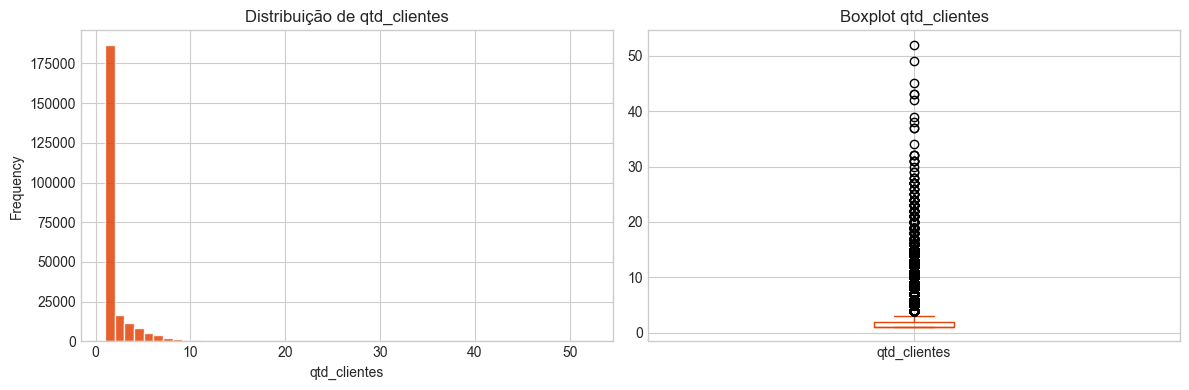

count   239898.00
mean         2.02
std          2.13
min          1.00
25%          1.00
50%          1.00
75%          2.00
95%          6.00
99%         11.00
max         52.00
Name: qtd_clientes, dtype: float64


In [36]:
# ── 9.1 Visualização de qtd_clientes ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['qtd_clientes'].plot.hist(bins=50, ax=axes[0], color='#E24307', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição de qtd_clientes')
axes[0].set_xlabel('qtd_clientes')

df['qtd_clientes'].plot.box(ax=axes[1], vert=True, color='#E24307')
axes[1].set_title('Boxplot qtd_clientes')

plt.tight_layout()
plt.show()
print(df['qtd_clientes'].describe(percentiles=[.25, .5, .75, .95, .99]))

In [37]:
# ── 9.2 IQR para qtd_clientes ────────────────────────────────────────────────
Q1 = df['qtd_clientes'].quantile(0.25)
Q3 = df['qtd_clientes'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_iqr = df[(df['qtd_clientes'] < lim_inf) | (df['qtd_clientes'] > lim_sup)]
print(f'Limites IQR     : [{lim_inf:.0f}, {lim_sup:.0f}]')
print(f'Outliers por IQR: {len(outliers_iqr):,} ({len(outliers_iqr)/len(df)*100:.1f}%)')
display(outliers_iqr[['centro_nv2', 'mes_ano', 'classificacao', 'qtd_clientes', 'flag']]
        .sort_values('qtd_clientes', ascending=False).head(15))

# ── 9.3 Z-Score ───────────────────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df['qtd_clientes'].dropna()))
outliers_z = df.loc[df['qtd_clientes'].dropna().index][z_scores > 3]
print(f'\nOutliers por Z-Score (|z|>3): {len(outliers_z):,}')

# Flag de outlier na base principal
df['outlier_qtd'] = False
df.loc[(df['qtd_clientes'] < lim_inf) | (df['qtd_clientes'] > lim_sup), 'outlier_qtd'] = True

Limites IQR     : [-0, 4]
Outliers por IQR: 37,078 (15.5%)


,centro_nv2,mes_ano,classificacao,qtd_clientes,flag
957,L5001-RIBEIRAO PRETO (0217),2026-02-01,promotor,52,regular
90408,L5099-VILA MATILDE (1421),2026-02-01,promotor,49,regular
113457,L5123-SAO VICENTE,2026-01-01,promotor,45,regular
84399,L5092-VILA AUGUSTA (1374),2026-02-01,promotor,43,tocadora
100335,L5109-SANTOS POMPEIA,2026-01-01,promotor,43,regular
157403,L5173-PERUIBE,2026-01-01,promotor,42,regular
13685,L5016-ANDRADINA (0573),2026-02-01,promotor,39,regular
156418,L5172-PRESIDENTE PRUDENTE,2026-04-01,promotor,38,regular
53279,L5057-BOQUEIRAO (1289),2026-01-01,promotor,37,regular
181245,L5201-ANA COSTA,2026-01-01,promotor,37,regular



Outliers por Z-Score (|z|>3): 5,180


In [38]:
# ── 9.4 NPS por loja — outliers de performance ────────────────────────────────
nps_stats = nps_loja_mes['nps'].describe(percentiles=[.05, .25, .75, .95])
display(nps_stats)

Q1_nps  = nps_loja_mes['nps'].quantile(0.25)
Q3_nps  = nps_loja_mes['nps'].quantile(0.75)
IQR_nps = Q3_nps - Q1_nps

outliers_nps = nps_loja_mes[
    (nps_loja_mes['nps'] < Q1_nps - 1.5*IQR_nps) |
    (nps_loja_mes['nps'] > Q3_nps + 1.5*IQR_nps)
]
print(f'\nLojas com NPS outlier: {len(outliers_nps)}')
display(outliers_nps[['centro_nv2', 'mes_ano_dt', 'flag', 'nps', 'total_respostas']].sort_values('nps'))

# ── 9.5 Taxa de resposta > 100% (possível erro nos dados) ─────────────────────
taxa_alta = nps_loja_mes[nps_loja_mes['taxa_resposta_pct'] > 100]
print(f'\nRegistros com taxa de resposta > 100%: {len(taxa_alta)}')
if len(taxa_alta):
    display(taxa_alta[['centro_nv2', 'mes_ano_dt', 'total_respostas', 'transacoes', 'taxa_resposta_pct']])

count   3621.00
mean      87.22
std        5.92
min       48.89
5%        76.34
25%       84.21
75%       91.35
95%       95.08
max      100.00
Name: nps, dtype: float64


Lojas com NPS outlier: 95


,centro_nv2,mes_ano_dt,flag,nps,total_respostas
272,L5020-VILA MARIANA 2 (0779),2025-01,regular,48.89,90
1154,L5082-VILA ANDRADE (1346),2025-03,regular,53.62,69
1184,L5084-GUAIPA (1349),2025-01,tocadora,54.17,48
273,L5020-VILA MARIANA 2 (0779),2025-02,regular,56.25,48
176,L5014-ROUXINOL (0567),2025-01,tocadora,58.21,67
65,L5005-BROOKLIN (0475),2025-02,tocadora,59.32,59
100,L5007-KLABIN (0496),2025-05,tocadora,59.32,59
2784,L5206-CACHOEIRINHA,2025-01,tocadora,59.83,117
98,L5007-KLABIN (0496),2025-03,tocadora,60.00,85
2396,L5174-PERI PERI,2026-01,tocadora,60.24,83



Registros com taxa de resposta > 100%: 0


<div style="
    background: linear-gradient(90deg, #ff632a 0%, #ffefea 100%);
    border-left: 6px solid #7e2200;
    color: white;
    padding: 12px 20px;
    border-radius: 8px;
    font-family: 'Segoe UI', sans-serif;
    font-size: 16px;
    font-weight: bold;
    letter-spacing: 0.5px;
    margin: 10px 0 5px 0;
    box-shadow: 0px 2px 6px rgba(226,67,7,0.3);
"> 10. Análise Exploratória</div>

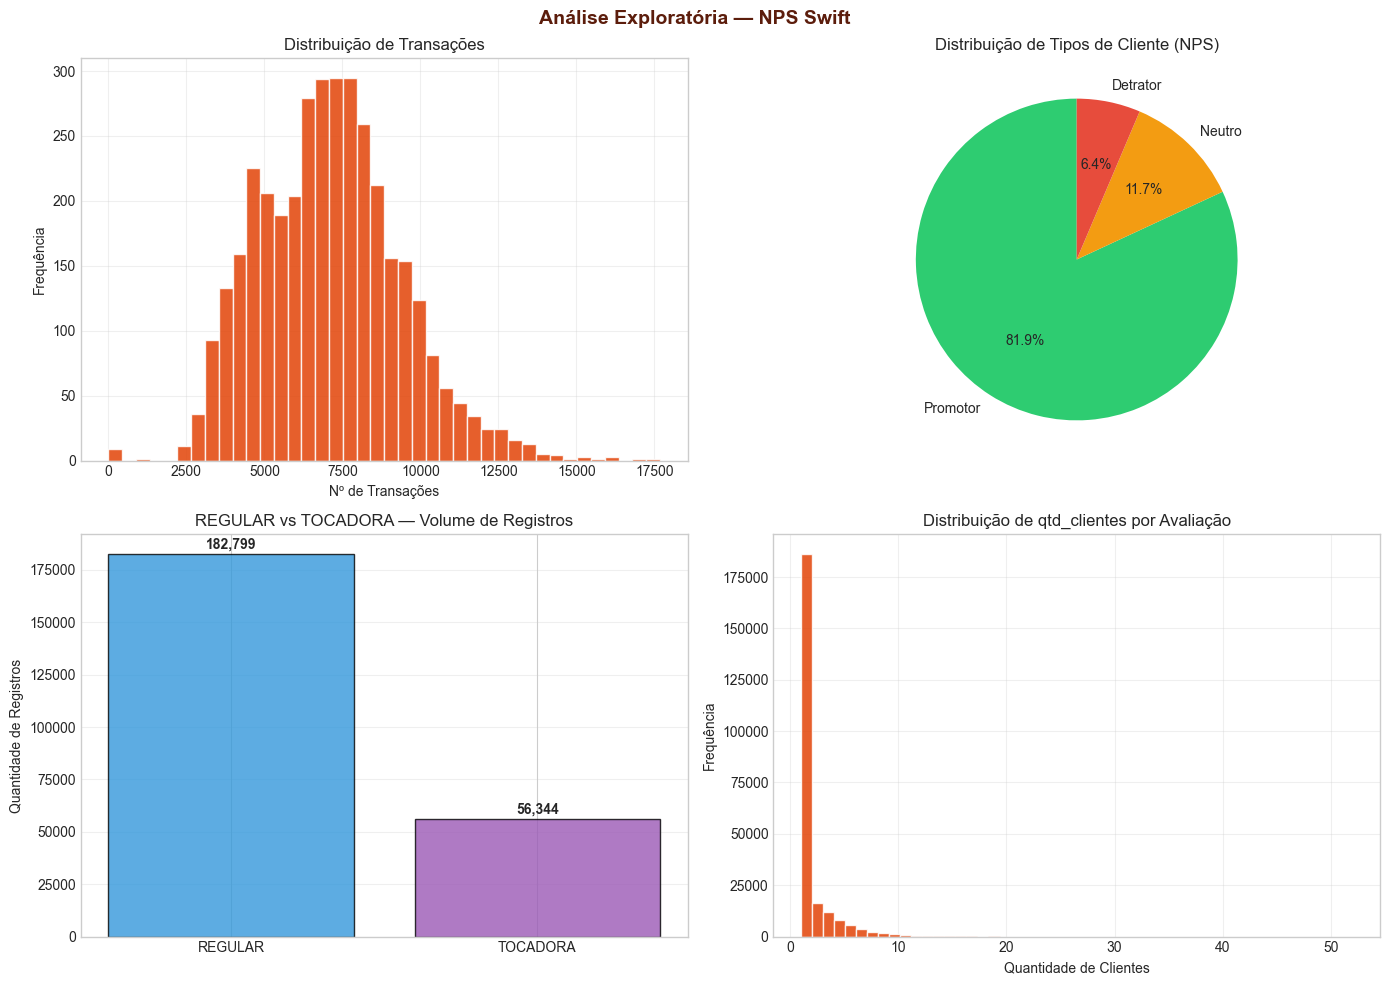

 Visualizações geradas


In [39]:
# ── 10.1 Distribuição geral de tipos de cliente ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise Exploratória — NPS Swift', fontsize=14, fontweight='bold', color='#5c1d0c')

# Gráfico 1: Distribuição de transações
axes[0, 0].hist(df_t['transacoes'].dropna(), bins=40, color='#E24307', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Distribuição de Transações')
axes[0, 0].set_xlabel('Nº de Transações')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Tipos de cliente (pizza)
tipo_counts = df['classificacao'].str.capitalize().value_counts()
cores_pizza = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0, 1].pie(tipo_counts.values, labels=tipo_counts.index, autopct='%1.1f%%',
               colors=cores_pizza[:len(tipo_counts)], startangle=90)
axes[0, 1].set_title('Distribuição de Tipos de Cliente (NPS)')

# Gráfico 3: REGULAR vs TOCADORA (barras)
flag_counts = df[df['flag'].isin(['regular', 'tocadora'])]['flag'].str.upper().value_counts()
bars = axes[1, 0].bar(flag_counts.index, flag_counts.values, color=['#3498db', '#9b59b6'],
                      edgecolor='black', alpha=0.8)
axes[1, 0].set_title('REGULAR vs TOCADORA — Volume de Registros')
axes[1, 0].set_ylabel('Quantidade de Registros')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar in bars:
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                    f'{int(bar.get_height()):,}', ha='center', va='bottom', fontweight='bold')

# Gráfico 4: Distribuição de qtd_clientes
axes[1, 1].hist(df['qtd_clientes'], bins=50, color='#E24307', edgecolor='white', alpha=0.85)
axes[1, 1].set_title('Distribuição de qtd_clientes por Avaliação')
axes[1, 1].set_xlabel('Quantidade de Clientes')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(' Visualizações geradas')

In [40]:
# ── 10.2 NPS evolução temporal por Flag ──────────────────────────────────────
nps_plot = nps_flag_mes[nps_flag_mes['flag'].isin(['regular', 'tocadora'])].copy()
nps_plot['mes_ano_str'] = nps_plot['mes_ano_dt'].astype(str)

fig = px.line(
    nps_plot.sort_values('mes_ano_str'),
    x='mes_ano_str', y='nps', color='flag',
    color_discrete_map={'regular': '#3498db', 'tocadora': '#9b59b6'},
    markers=True,
    title='Evolução do NPS — REGULAR vs TOCADORA',
    labels={'mes_ano_str': 'Período', 'nps': 'NPS (%)', 'flag': 'Tipo de Gerente'}
)
fig.update_layout(hovermode='x unified')
fig.show()

In [41]:
# ── 10.3 Estatísticas de comentários por tipo de cliente e flag ──────────────
print('=== DISTRIBUIÇÃO DE COMENTÁRIOS POR TIPO DE CLIENTE ===')
coment_tipo = df[df['tem_comentario']].groupby('classificacao').size()
for tipo, count in coment_tipo.items():
    pct = count / df['tem_comentario'].sum() * 100
    print(f'  {tipo.upper():12s}: {count:>7,} ({pct:.1f}%)')

print()
print('=== DISTRIBUIÇÃO DE COMENTÁRIOS POR FLAG ===')
coment_flag = df[df['tem_comentario']].groupby('flag').size()
for flag, count in coment_flag.items():
    pct = count / df['tem_comentario'].sum() * 100
    print(f'  {flag.upper():12s}: {count:>7,} ({pct:.1f}%)')

print()
print('=== ESTATÍSTICAS DE COMPRIMENTO DOS COMENTÁRIOS ===')
print(df[df['tem_comentario']]['qtd_palavras'].describe())

=== DISTRIBUIÇÃO DE COMENTÁRIOS POR TIPO DE CLIENTE ===
  DETRATOR    :  11,994 (9.3%)
  NEUTRO      :  15,938 (12.4%)
  PROMOTOR    : 100,401 (78.2%)

=== DISTRIBUIÇÃO DE COMENTÁRIOS POR FLAG ===
  REGULAR     :  98,592 (76.8%)
  TOCADORA    :  29,340 (22.9%)

=== ESTATÍSTICAS DE COMPRIMENTO DOS COMENTÁRIOS ===
count   128333.00
mean        15.87
std         20.14
min          0.00
25%          5.00
50%          9.00
75%         20.00
max       1309.00
Name: qtd_palavras, dtype: float64


<div style="
    background: linear-gradient(90deg, #ff632a 0%, #ffefea 100%);
    border-left: 6px solid #7e2200;
    color: white;
    padding: 12px 20px;
    border-radius: 8px;
    font-family: 'Segoe UI', sans-serif;
    font-size: 16px;
    font-weight: bold;
    letter-spacing: 0.5px;
    margin: 10px 0 5px 0;
    box-shadow: 0px 2px 6px rgba(226,67,7,0.3);
"> 11. Exportação das Bases Tratadas</div>

In [45]:
# ── 11.1 Base principal (nível registro) ─────────────────────────────────────
df_merge.to_parquet('df_avaliacoes_tratado.parquet', index=False)
df_merge.to_csv('df_avaliacoes_tratado.csv', index=False, sep=';', encoding='utf-8-sig')

# ── 11.2 NPS consolidado por loja × mês ──────────────────────────────────────
nps_loja_mes.to_parquet('df_nps_loja_mes.parquet', index=False)
nps_loja_mes.to_csv('df_nps_loja_mes.csv', index=False, sep=';', encoding='utf-8-sig')

# ── 11.3 Comentários limpos (para NLP) ────────────────────────────────────────
df_comentarios = df_merge[df_merge['tem_comentario']].copy()
df_comentarios.to_parquet('df_comentarios_nlp.parquet', index=False)
df_comentarios.to_csv('df_comentarios_nlp.csv', index=False, sep=';', encoding='utf-8-sig')

# ── 11.4 Resumo em JSON ────────────────────────────────────────────────────────
resumo = {
    "data_processamento": datetime.now().strftime("%d/%m/%Y %H:%M:%S"),
    "dataset_avaliacoes": {
        "registros"            : len(df_merge),
        "lojas_unicas"         : int(df_merge['centro_nv2'].nunique()),
        "periodos_cobertos"    : int(df_merge['mes_ano_dt'].nunique()),
        "com_comentario"       : int(df_merge['tem_comentario'].sum()),
        "outliers_qtd_clientes": int(df_merge['outlier_qtd'].sum()),
        "cobertura_transacoes" : round(df_merge['transacoes'].notna().mean() * 100, 1),
    },
    "dataset_transacoes": {
        "registros"  : len(df_t),
        "lojas_unicas": int(df_t['centro_nv2'].nunique()),
    },
    "nps_por_flag": nps_flag_mes.groupby('flag')['nps'].mean().round(2).to_dict(),
}

with open('resumo_preprocessamento.json', 'w', encoding='utf-8') as f:
    json.dump(resumo, f, ensure_ascii=False, indent=2)

print(' Exportações concluídas:')
print(f'   df_avaliacoes_tratado : {df_merge.shape}')
print(f'   df_nps_loja_mes       : {nps_loja_mes.shape}')
print(f'   df_comentarios_nlp    : {df_comentarios.shape}')

ArrowKeyError: A type extension with name pandas.period already defined

In [ ]:
print('=' * 58)
print('         RELATÓRIO DE PRÉ-PROCESSAMENTO')
print('=' * 58)
print(f'Registros originais (avaliações) : {len(df_aval):>10,}')
print(f'Registros após limpeza           : {len(df_merge):>10,}')
print(f'Lojas únicas                     : {df_merge["centro_nv2"].nunique():>10,}')
print(f'Períodos cobertos                : {df_merge["mes_ano_dt"].nunique():>10,}')
print(f'Com comentário real              : {df_merge["tem_comentario"].sum():>10,}')
print(f'Outliers em qtd_clientes         : {df_merge["outlier_qtd"].sum():>10,}')
print(f'Cobertura de transações          : {(df_merge["transacoes"].notna().mean()*100):>9.1f}%')
print()
print('Colunas na base final:')
for c in sorted(df_merge.columns):
    print(f'  - {c}')
print('=' * 58)